In [1]:
import pandas as pd

In [2]:
# 📂 File paths for raw healthcare data (relative paths from repo root)
train_beneficiary_path = '../data/raw/Train_Beneficiarydata-1542865627584.csv'
train_inpatient_path = '../data/raw/Train_Inpatientdata-1542865627584.csv'
train_outpatient_path = '../data/raw/Train_Outpatientdata-1542865627584.csv'
train_path = '../data/raw/Train-1542865627584.csv'

test_beneficiary_path = '../data/raw/Test_Beneficiarydata-1542969243754.csv'
test_inpatient_path = '../data/raw/Test_Inpatientdata-1542969243754.csv'
test_outpatient_path = '../data/raw/Test_Outpatientdata-1542969243754.csv'
test_path = '../data/raw/Test-1542969243754.csv'

In [3]:
# Load training datasets
train_beneficiary = pd.read_csv(train_beneficiary_path)
train_inpatient = pd.read_csv(train_inpatient_path)
train_outpatient = pd.read_csv(train_outpatient_path)
train = pd.read_csv(train_path)

In [4]:
# Load test datasets
test_beneficiary = pd.read_csv(test_beneficiary_path)
test_inpatient = pd.read_csv(test_inpatient_path)
test_outpatient = pd.read_csv(test_outpatient_path)
test = pd.read_csv(test_path)

In [5]:
# ✅ View summary
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (5410, 2)
Test shape: (1353, 1)


In [6]:
print("Initial structure of train_beneficiary:")
train_beneficiary.info()

Initial structure of train_beneficiary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   BeneID                           138556 non-null  object
 1   DOB                              138556 non-null  object
 2   DOD                              1421 non-null    object
 3   Gender                           138556 non-null  int64 
 4   Race                             138556 non-null  int64 
 5   RenalDiseaseIndicator            138556 non-null  object
 6   State                            138556 non-null  int64 
 7   County                           138556 non-null  int64 
 8   NoOfMonths_PartACov              138556 non-null  int64 
 9   NoOfMonths_PartBCov              138556 non-null  int64 
 10  ChronicCond_Alzheimer            138556 non-null  int64 
 11  ChronicCond_Heartfailure         13855

In [7]:
# CLEANING + FEATURE ENGINEERING
def data_cleaning_beneficiary(df):
    df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')
    df['DOD'] = pd.to_datetime(df['DOD'], errors='coerce')
    
    numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

    categorical_cols = df.select_dtypes(include=['object']).columns
    df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

    category_columns = ['Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County']
    for col in category_columns:
        if col in df.columns:
            df[col] = df[col].astype('category')

    return df

In [8]:
def add_engineered_features(df):
    df['AgeAtDeathOrLastClaim'] = ((df['DOD'].fillna(pd.Timestamp('2020-01-01')) - df['DOB']).dt.days // 365)
    return df

# APPLY LOGIC
train_beneficiary = add_engineered_features(data_cleaning_beneficiary(train_beneficiary))
test_beneficiary = add_engineered_features(data_cleaning_beneficiary(test_beneficiary))

In [9]:
print("Post-cleaning structure of train_beneficiary:")
train_beneficiary.info()

Post-cleaning structure of train_beneficiary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 26 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   BeneID                           138556 non-null  object        
 1   DOB                              138556 non-null  datetime64[ns]
 2   DOD                              1421 non-null    datetime64[ns]
 3   Gender                           138556 non-null  category      
 4   Race                             138556 non-null  category      
 5   RenalDiseaseIndicator            138556 non-null  category      
 6   State                            138556 non-null  category      
 7   County                           138556 non-null  category      
 8   NoOfMonths_PartACov              138556 non-null  int64         
 9   NoOfMonths_PartBCov              138556 non-null  int64         
 10

In [10]:
print("📊 Original train_inpatient structure:")
print(train_inpatient.info())

print("📊 Original test_outpatient structure:")
print(test_outpatient.info())


📊 Original train_inpatient structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40474 entries, 0 to 40473
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   BeneID                  40474 non-null  object 
 1   ClaimID                 40474 non-null  object 
 2   ClaimStartDt            40474 non-null  object 
 3   ClaimEndDt              40474 non-null  object 
 4   Provider                40474 non-null  object 
 5   InscClaimAmtReimbursed  40474 non-null  int64  
 6   AttendingPhysician      40362 non-null  object 
 7   OperatingPhysician      23830 non-null  object 
 8   OtherPhysician          4690 non-null   object 
 9   AdmissionDt             40474 non-null  object 
 10  ClmAdmitDiagnosisCode   40474 non-null  object 
 11  DeductibleAmtPaid       39575 non-null  float64
 12  DischargeDt             40474 non-null  object 
 13  DiagnosisGroupCode      40474 non-null  object 
 14  

In [11]:
# ================================
# CLEAN INPATIENT & OUTPATIENT DATA
# ================================

# General outlier removal
def winsorize_column(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

def data_cleaning_general(df):
    numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
    for col in numerical_columns:
        if df[col].notnull().sum() > 1000 and df[col].std() > 0:
            df[col] = winsorize_column(df[col])
    return df



def convert_date_columns(df, date_columns):
    for col in date_columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

def convert_to_category(df, categorical_columns):
    df[categorical_columns] = df[categorical_columns].astype('category')
    return df




In [12]:
# ========== APPLYING LOGIC ==========

# Clean numeric fields
train_inpatient = data_cleaning_general(train_inpatient)
test_inpatient = data_cleaning_general(test_inpatient)
train_outpatient = data_cleaning_general(train_outpatient)
test_outpatient = data_cleaning_general(test_outpatient)

In [13]:
# Convert date columns
date_columns_inpatient = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt']
train_inpatient = convert_date_columns(train_inpatient, date_columns_inpatient)
test_inpatient = convert_date_columns(test_inpatient, date_columns_inpatient)

date_columns_outpatient = ['ClaimStartDt', 'ClaimEndDt']
train_outpatient = convert_date_columns(train_outpatient, date_columns_outpatient)
test_outpatient = convert_date_columns(test_outpatient, date_columns_outpatient)

In [14]:
# Convert to category
categorical_columns_inpatient = ['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',
                                 'ClmAdmitDiagnosisCode', 'DiagnosisGroupCode'] + \
                                [f'ClmDiagnosisCode_{i}' for i in range(1, 11)] + \
                                [f'ClmProcedureCode_{i}' for i in range(1, 7)]

categorical_columns_outpatient = ['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',
                                  'ClmAdmitDiagnosisCode'] + \
                                 [f'ClmDiagnosisCode_{i}' for i in range(1, 11)] + \
                                 [f'ClmProcedureCode_{i}' for i in range(1, 7)]

train_inpatient = convert_to_category(train_inpatient, categorical_columns_inpatient)
test_inpatient = convert_to_category(test_inpatient, categorical_columns_inpatient)
train_outpatient = convert_to_category(train_outpatient, categorical_columns_outpatient)
test_outpatient = convert_to_category(test_outpatient, categorical_columns_outpatient)

In [15]:
print("\n✅ Cleaned train_inpatient structure:")
print(train_inpatient.info())

print("\n✅ Cleaned test_outpatient structure:")
print(test_outpatient.info())



✅ Cleaned train_inpatient structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40474 entries, 0 to 40473
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   BeneID                  40474 non-null  object        
 1   ClaimID                 40474 non-null  object        
 2   ClaimStartDt            40474 non-null  datetime64[ns]
 3   ClaimEndDt              40474 non-null  datetime64[ns]
 4   Provider                40474 non-null  object        
 5   InscClaimAmtReimbursed  40474 non-null  int64         
 6   AttendingPhysician      40362 non-null  category      
 7   OperatingPhysician      23830 non-null  category      
 8   OtherPhysician          4690 non-null   category      
 9   AdmissionDt             40474 non-null  datetime64[ns]
 10  ClmAdmitDiagnosisCode   40474 non-null  category      
 11  DeductibleAmtPaid       39575 non-null  float64       
 12  Discharg

In [16]:
# ============================== #
# DATA QUALITY + CONSISTENCY CHECK
# ============================== #

# Referential integrity checks
missing_beneids_train_in = set(train_inpatient['BeneID']) - set(train_beneficiary['BeneID'])
missing_beneids_train_out = set(train_outpatient['BeneID']) - set(train_beneficiary['BeneID'])
missing_beneids_test_in = set(test_inpatient['BeneID']) - set(test_beneficiary['BeneID'])
missing_beneids_test_out = set(test_outpatient['BeneID']) - set(test_beneficiary['BeneID'])

In [17]:
# Dataset alignment function
def check_alignment(df_train, df_test):
    return {
        "columns_match": set(df_train.columns) == set(df_test.columns),
        "train_only": set(df_train.columns) - set(df_test.columns),
        "test_only": set(df_test.columns) - set(df_train.columns)
    }

alignment_main = check_alignment(train, test)
alignment_inpatient = check_alignment(train_inpatient, test_inpatient)
alignment_outpatient = check_alignment(train_outpatient, test_outpatient)

In [18]:
# Print results
print("Referential Integrity Check:")
print(f"Missing BeneIDs in Train Inpatient: {len(missing_beneids_train_in)}")
print(f"Missing BeneIDs in Train Outpatient: {len(missing_beneids_train_out)}")
print(f"Missing BeneIDs in Test Inpatient: {len(missing_beneids_test_in)}")
print(f"Missing BeneIDs in Test Outpatient: {len(missing_beneids_test_out)}\n")

print("Train/Test Dataset Alignment:")
print(f"Main Dataset Columns Match: {alignment_main['columns_match']}")
print(f"Inpatient Columns Match: {alignment_inpatient['columns_match']}")
print(f"Outpatient Columns Match: {alignment_outpatient['columns_match']}")
print(f"Extra in Train (Main): {alignment_main['train_only']}")
print(f"Extra in Test (Main): {alignment_main['test_only']}")

Referential Integrity Check:
Missing BeneIDs in Train Inpatient: 0
Missing BeneIDs in Train Outpatient: 0
Missing BeneIDs in Test Inpatient: 0
Missing BeneIDs in Test Outpatient: 0

Train/Test Dataset Alignment:
Main Dataset Columns Match: False
Inpatient Columns Match: True
Outpatient Columns Match: True
Extra in Train (Main): {'PotentialFraud'}
Extra in Test (Main): set()


C:\Users\melny\AppData\Local\Temp\ipykernel_6968\3309594946.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


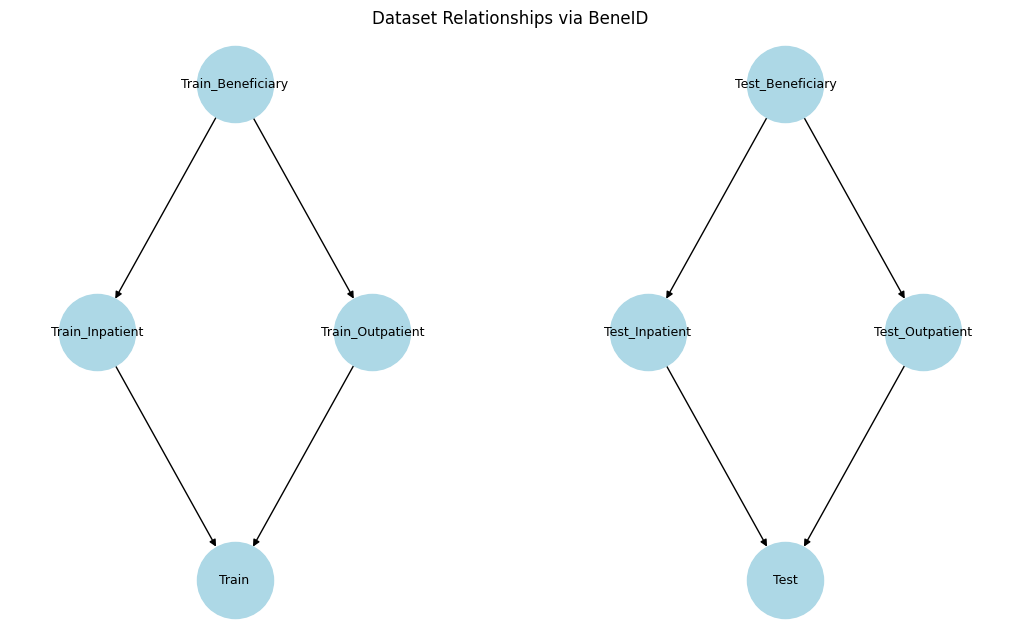

In [19]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()

# Nodes
G.add_node("Train_Beneficiary")
G.add_node("Test_Beneficiary")
G.add_node("Train_Inpatient")
G.add_node("Train_Outpatient")
G.add_node("Test_Inpatient")
G.add_node("Test_Outpatient")
G.add_node("Train")
G.add_node("Test")

# Edges (Data relationship through BeneID)
G.add_edges_from([
    ("Train_Beneficiary", "Train_Inpatient"),
    ("Train_Beneficiary", "Train_Outpatient"),
    ("Test_Beneficiary", "Test_Inpatient"),
    ("Test_Beneficiary", "Test_Outpatient"),
    ("Train_Inpatient", "Train"),
    ("Train_Outpatient", "Train"),
    ("Test_Inpatient", "Test"),
    ("Test_Outpatient", "Test")
])

# Layout
pos = {
    "Train_Beneficiary": (-2, 2),
    "Test_Beneficiary": (2, 2),
    "Train_Inpatient": (-3, 0),
    "Train_Outpatient": (-1, 0),
    "Test_Inpatient": (1, 0),
    "Test_Outpatient": (3, 0),
    "Train": (-2, -2),
    "Test": (2, -2)
}

plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=3000, font_size=9, arrows=True)
plt.title("Dataset Relationships via BeneID")
plt.axis("off")
plt.tight_layout()
plt.show()

## Export Cleaned Data for Downstream AI Agent

This section exports the cleaned and validated healthcare datasets into local Parquet files for downstream use by a companion Healthcare AI Agent project.

The exported Parquet files are intentionally excluded from GitHub and can be regenerated locally by rerunning this notebook after placing the raw Kaggle CSV files into `data/raw/`.

In [20]:
from pathlib import Path

# Create processed directory if it does not exist
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Dictionary of cleaned datasets
cleaned_tables = {
    "train_beneficiary_clean": train_beneficiary,
    "test_beneficiary_clean": test_beneficiary,
    "train_inpatient_clean": train_inpatient,
    "test_inpatient_clean": test_inpatient,
    "train_outpatient_clean": train_outpatient,
    "test_outpatient_clean": test_outpatient,
    "train_labels_clean": train,
    "test_labels_clean": test,
}

# Export all cleaned datasets to Parquet
for name, df in cleaned_tables.items():
    output_path = processed_dir / f"{name}.parquet"

    df.to_parquet(output_path, index=False)

    print(f"Exported: {output_path}")
    print(f"Shape: {df.shape}")

Exported: ..\data\processed\train_beneficiary_clean.parquet
Shape: (138556, 26)
Exported: ..\data\processed\test_beneficiary_clean.parquet
Shape: (63968, 26)
Exported: ..\data\processed\train_inpatient_clean.parquet
Shape: (40474, 30)
Exported: ..\data\processed\test_inpatient_clean.parquet
Shape: (9551, 30)
Exported: ..\data\processed\train_outpatient_clean.parquet
Shape: (517737, 27)
Exported: ..\data\processed\test_outpatient_clean.parquet
Shape: (125841, 27)
Exported: ..\data\processed\train_labels_clean.parquet
Shape: (5410, 2)
Exported: ..\data\processed\test_labels_clean.parquet
Shape: (1353, 1)
